# Data Visualization for Socio-Economic Analysis

This notebook provides a comprehensive visualization of the integrated dataset, covering education (APM, RLS), health (Stunting), and economic indicators (PPK, IPM) across Indonesian provinces.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Konfigurasi
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Ini untuk ngeload data
df = pd.read_csv('dataset/integrated_filled.csv')
df.head()

,Tahun,Provinsi,APM_SD,APM_SMP,APM_SMA,IPM_Laki_Laki,IPM_Perempuan,PPK,PSN (Stunting),RLS
0,2003,Aceh,95.36,78.74,61.63,79.85,74.35,5633.00,51.1,7.47
1,2003,Bali,91.58,68.63,53.36,81.96,78.53,11366.47,41.4,6.75
2,2003,Banten,93.77,62.28,36.41,80.81,75.62,9327.60,9.2,7.13
3,2003,Bengkulu,91.99,60.44,42.54,79.34,73.14,6266.33,30.3,7.14
4,2003,Daerah Istimewa Yogyakarta,91.98,79.06,59.77,85.08,81.32,10286.47,29.7,7.67


## 1. Descriptive Statistics

Understanding the distribution and range of each indicator.

In [ ]:
df.describe()

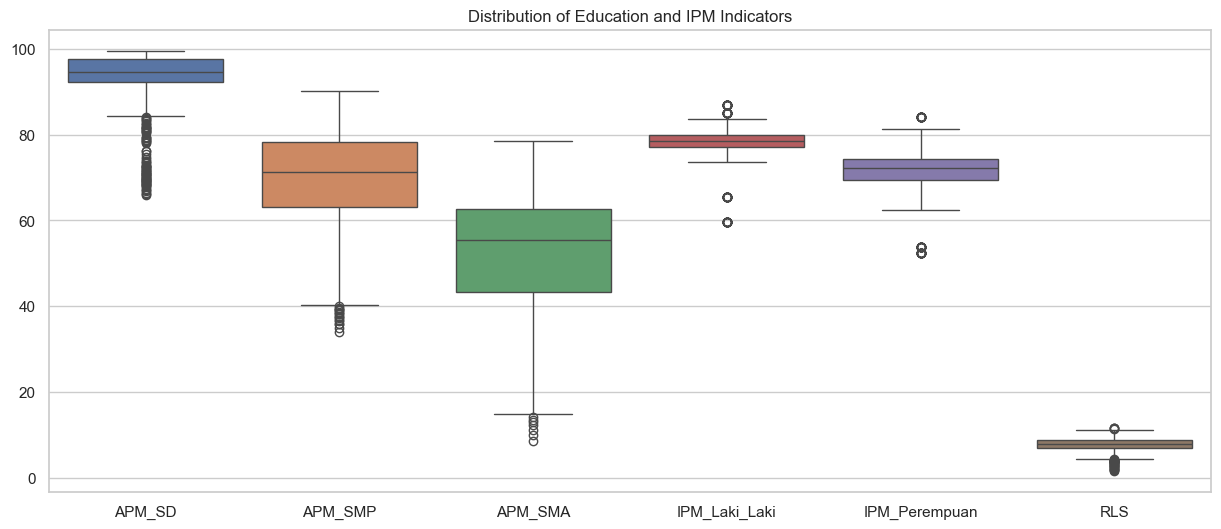

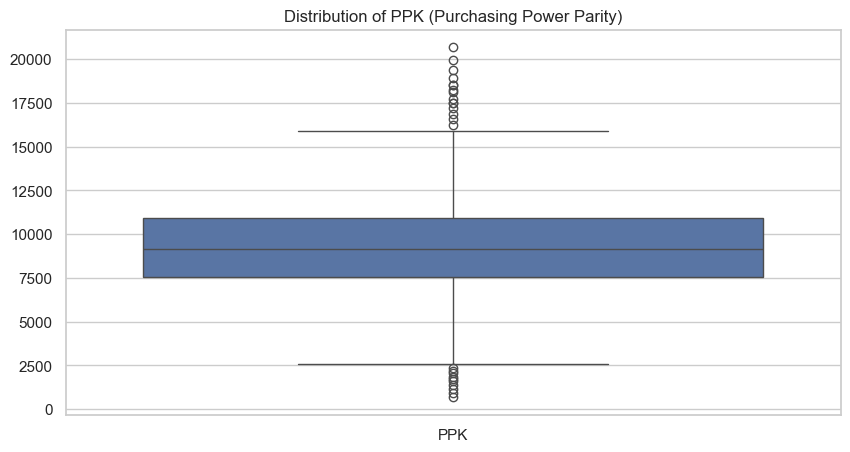

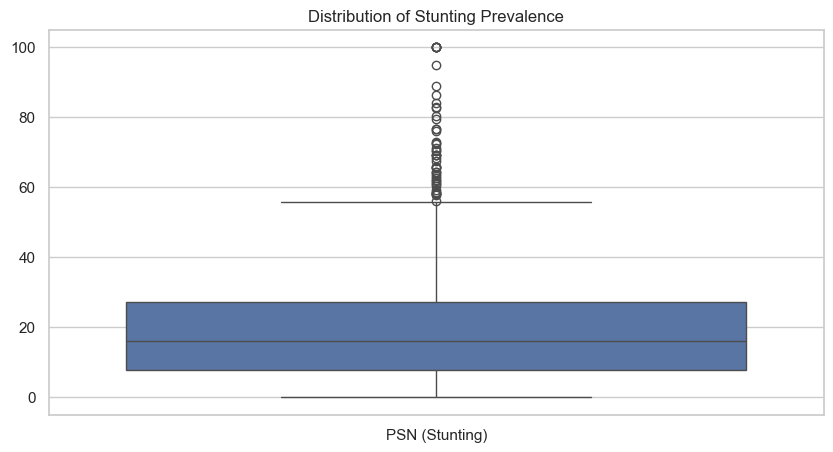

In [2]:
# Boxplot to see distribution across all data points
cols_to_plot = ['APM_SD', 'APM_SMP', 'APM_SMA', 'IPM_Laki_Laki', 'IPM_Perempuan', 'RLS']
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[cols_to_plot])
plt.title('Distribution of Education and IPM Indicators')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['PPK']])
plt.title('Distribution of PPK (Purchasing Power Parity)')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['PSN (Stunting)']])
plt.title('Distribution of Stunting Prevalence')
plt.show()

## 2. Correlation Analysis

Exploring how different indicators relate to one another.

In [ ]:
corr = df.drop(columns=['Tahun', 'Provinsi']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Socio-Economic Indicators')
plt.show()

## 3. Trend Analysis Over Time

How have these indicators improved nationally (average) over the years?

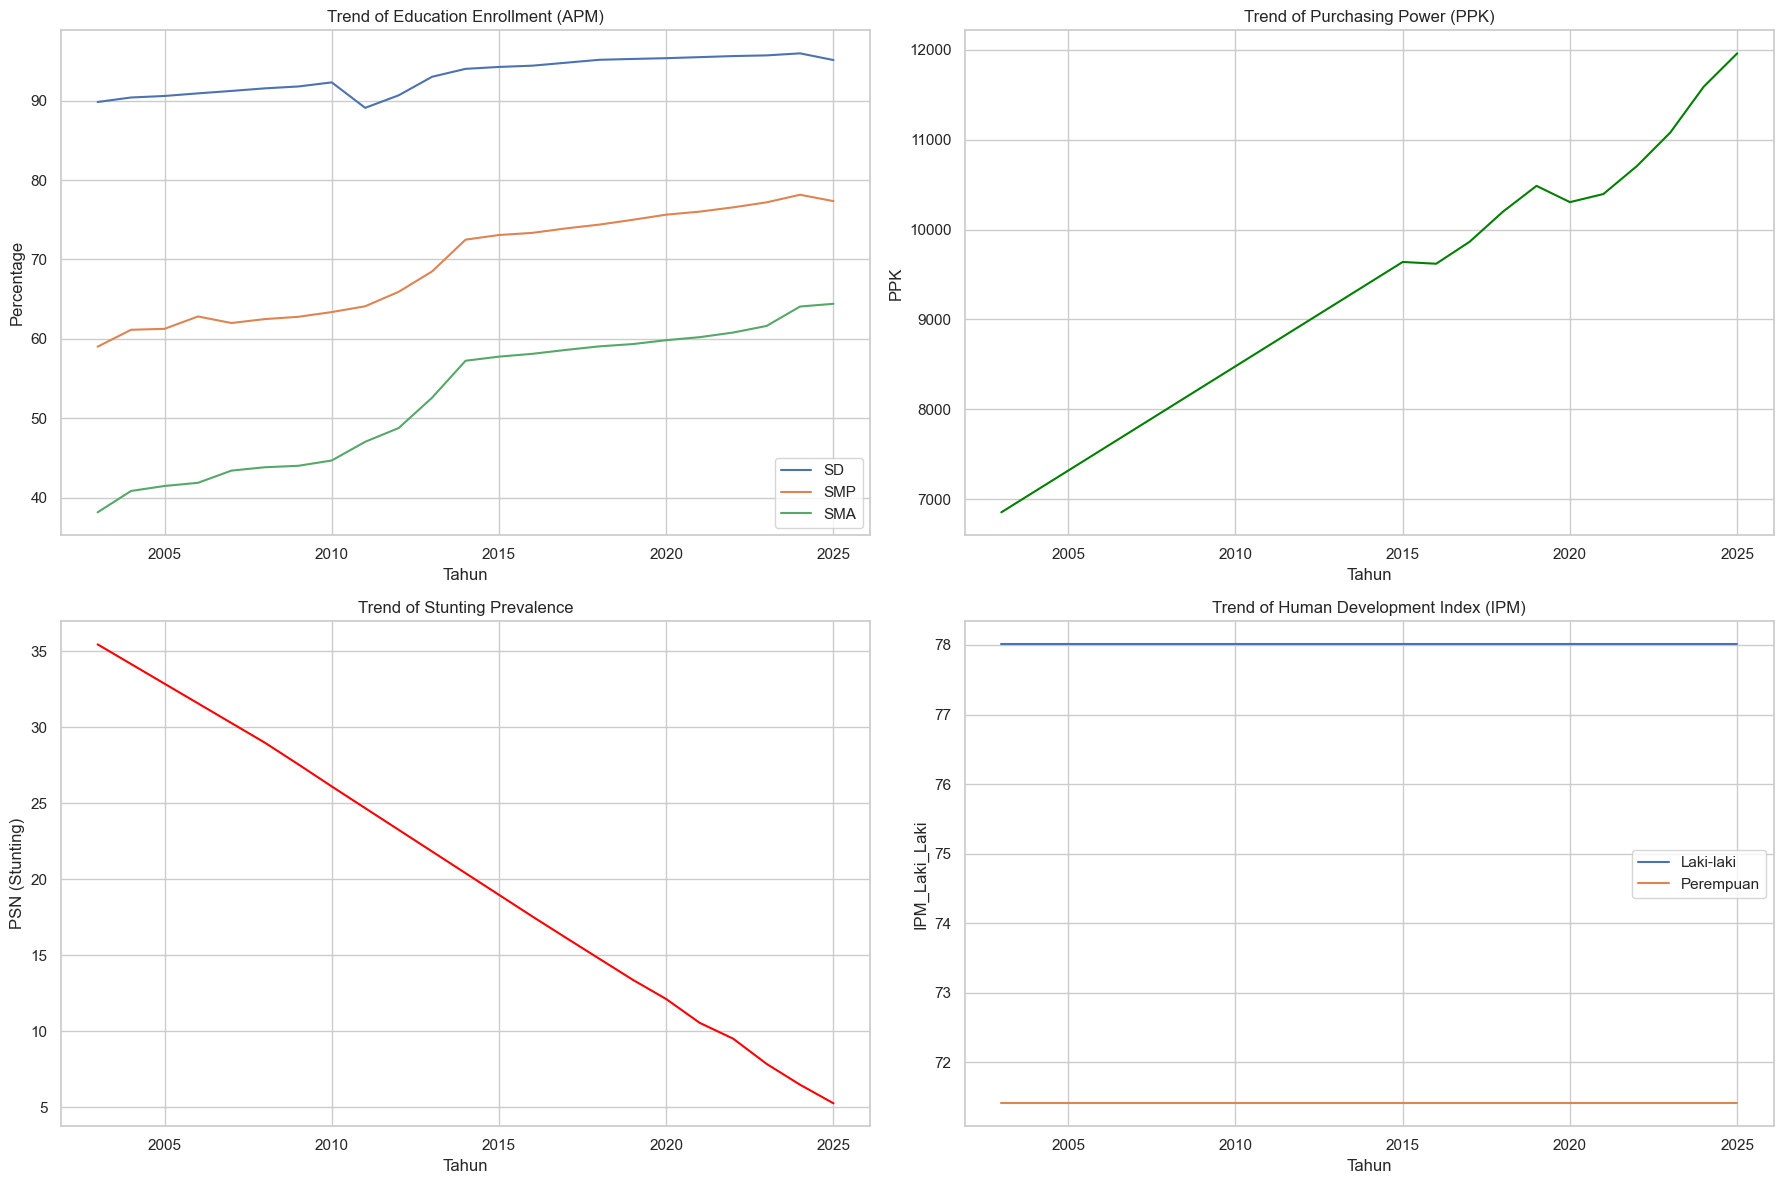

In [3]:
yearly_avg = df.groupby('Tahun').mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Education Trend
sns.lineplot(data=yearly_avg, x='Tahun', y='APM_SD', label='SD', ax=axes[0, 0])
sns.lineplot(data=yearly_avg, x='Tahun', y='APM_SMP', label='SMP', ax=axes[0, 0])
sns.lineplot(data=yearly_avg, x='Tahun', y='APM_SMA', label='SMA', ax=axes[0, 0])
axes[0, 0].set_title('Trend of Education Enrollment (APM)')
axes[0, 0].set_ylabel('Percentage')

# Economic Trend
sns.lineplot(data=yearly_avg, x='Tahun', y='PPK', ax=axes[0, 1], color='green')
axes[0, 1].set_title('Trend of Purchasing Power (PPK)')

# Health Trend
sns.lineplot(data=yearly_avg, x='Tahun', y='PSN (Stunting)', ax=axes[1, 0], color='red')
axes[1, 0].set_title('Trend of Stunting Prevalence')

# IPM Trend
sns.lineplot(data=yearly_avg, x='Tahun', y='IPM_Laki_Laki', label='Laki-laki', ax=axes[1, 1])
sns.lineplot(data=yearly_avg, x='Tahun', y='IPM_Perempuan', label='Perempuan', ax=axes[1, 1])
axes[1, 1].set_title('Trend of Human Development Index (IPM)')

plt.tight_layout()
plt.show()

## 4. Key Relationships

Visualizing strong correlations identified in the heatmap.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PPK vs RLS
sns.regplot(data=df, x='PPK', y='RLS', ax=axes[0], scatter_kws={'alpha':0.5})
axes[0].set_title('Relationship between PPK and Mean Years of Schooling (RLS)')

# APM_SMA vs IPM_Perempuan
sns.regplot(data=df, x='APM_SMA', y='IPM_Perempuan', ax=axes[1], color='purple', scatter_kws={'alpha':0.5})
axes[1].set_title('Relationship between SMA Enrollment and Female IPM')

plt.show()

## 5. Provincial Disparities (Latest Year)

Comparing performance across provinces for the most recent year in the dataset.

In [ ]:
latest_year = df['Tahun'].max()
df_latest = df[df['Tahun'] == latest_year].sort_values('IPM_Perempuan', ascending=False)

plt.figure(figsize=(12, 12))
sns.barplot(data=df_latest, x='IPM_Perempuan', y='Provinsi', hue='Provinsi', palette='viridis', legend=False)
plt.title(f'Female IPM across Provinces in {latest_year}')
plt.show()

In [ ]:
df_latest_stunting = df[df['Tahun'] == latest_year].sort_values('PSN (Stunting)', ascending=True)

plt.figure(figsize=(12, 12))
sns.barplot(data=df_latest_stunting, x='PSN (Stunting)', y='Provinsi', hue='Provinsi', palette='magma', legend=False)
plt.title(f'Stunting Prevalence across Provinces in {latest_year} (Lower is better)')
plt.show()

## 6. Multivariate Analysis

A pairplot to see distributions and scatter plots for all indicators simultaneously.

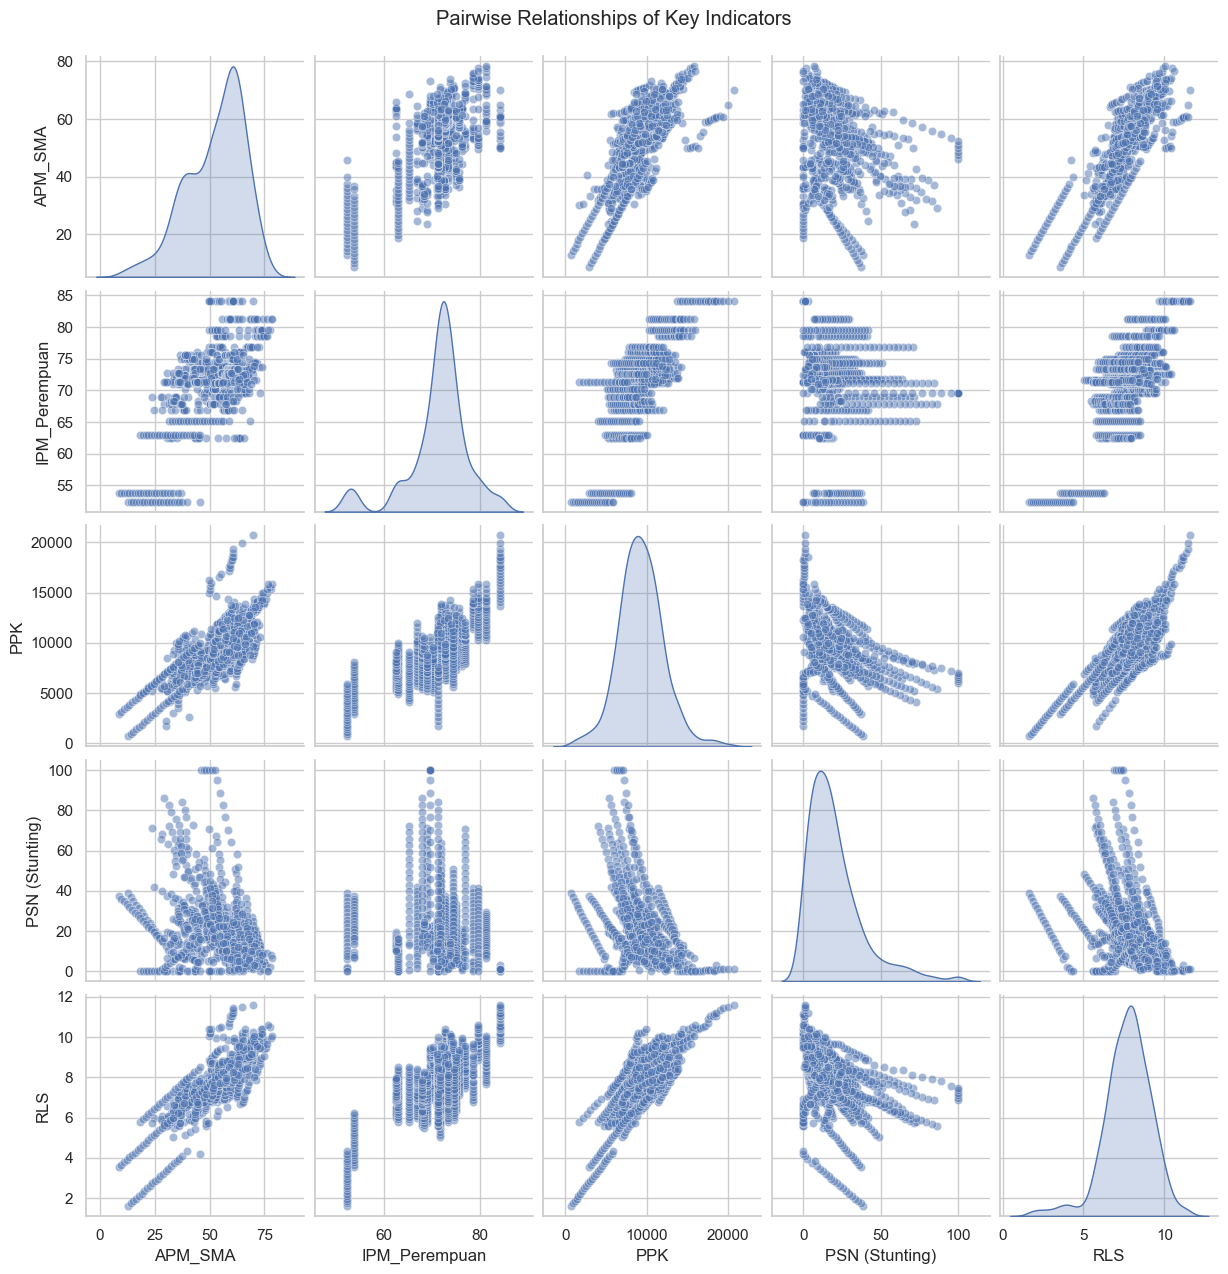

In [4]:
# Filter columns for pairplot to keep it readable
pairplot_cols = ['APM_SMA', 'IPM_Perempuan', 'PPK', 'PSN (Stunting)', 'RLS']
sns.pairplot(df[pairplot_cols], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships of Key Indicators', y=1.02)
plt.show()